In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [43]:
df = pd.read_csv("data/sentiment.csv")

In [44]:
df["Sentiment"] = (
    df["Sentiment"].astype(str).str.strip().str.lower()
)
df.head()
df.info()
df.shape
df.isnull().sum()
df.duplicated().sum()
df["Sentiment"].value_counts()
print(df["Sentiment"].unique())
for label in sorted(df["Sentiment"].astype(str).unique()):
    print(repr(label))


<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB
<StringArray>
[            'positive',             'negative',              'neutral',
                'anger',     

Text         0
Sentiment    0
dtype: int64
count    112.000000
mean       5.830357
std        7.028755
min        2.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       45.000000
Name: count, dtype: float64
Sentiment
positive       45
joy            44
excitement     37
contentment    19
neutral        18
gratitude      18
curiosity      16
serenity       15
happy          14
despair        11
Name: count, dtype: int64
Index([], dtype='str', name='Sentiment')


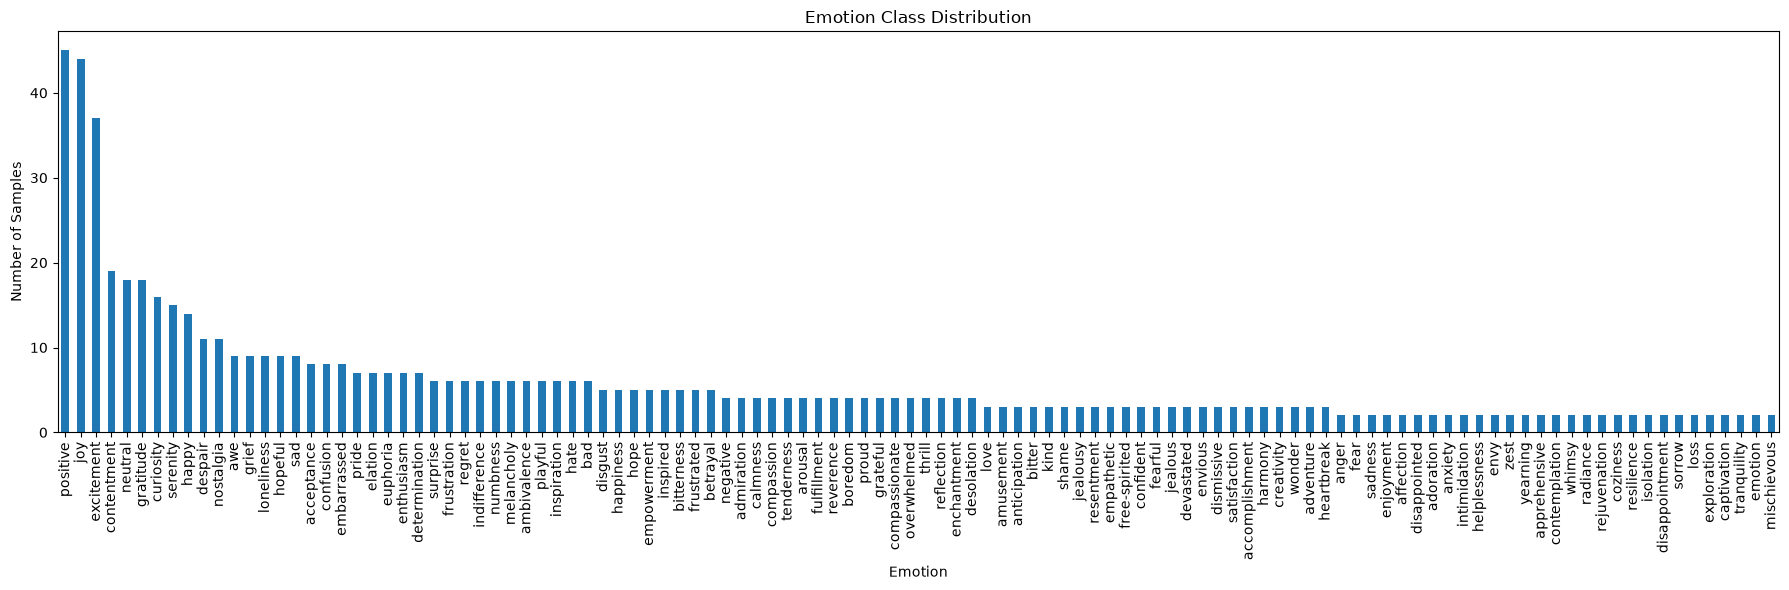

In [ ]:
#df.columns.tolist()
df = df[["Text", "Sentiment"]]
df.columns.tolist()
print(df.isnull().sum())

X = df["Text"]
y = df["Sentiment"]
df["Sentiment"].value_counts().sort_values()

class_counts = df["Sentiment"].value_counts()
print(class_counts.describe())
print(class_counts.head(10))
rare_classes = class_counts[class_counts < 2].index
print(rare_classes)

df = df[~df["Sentiment"].isin(rare_classes)]

df["Sentiment"].value_counts().sort_values()
df["Sentiment"].isin(rare_classes).any()

class_counts.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(18, 6)
)

plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show() #long tail distribution, is most likely cause of accuracy lower than 50% 
#and other relatively low metrics. The data itself is very imbalanced and skewed.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)
print(type(X_train_tfidf))

(522, 2031)
(131, 2031)
<class 'scipy.sparse._csr.csr_matrix'>


In [50]:
linear_SVM = SVC(
    kernel="linear",
    random_state=42
)
linear_SVM.fit(X_train_tfidf, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [55]:
y_pred_linear = linear_SVM.predict(X_test_tfidf)
print("ACCURACY:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))
cm = confusion_matrix(y_test, y_pred_linear)
print(cm.shape)

ACCURACY: 0.48091603053435117
                precision    recall  f1-score   support

    acceptance       1.00      1.00      1.00         2
accomplishment       0.00      0.00      0.00         1
    admiration       0.00      0.00      0.00         1
     adventure       0.00      0.00      0.00         1
   ambivalence       1.00      1.00      1.00         1
     amusement       0.00      0.00      0.00         1
  anticipation       0.00      0.00      0.00         1
       arousal       1.00      1.00      1.00         1
           awe       0.33      0.50      0.40         2
           bad       0.00      0.00      0.00         1
      betrayal       0.00      0.00      0.00         1
        bitter       0.00      0.00      0.00         1
    bitterness       0.00      0.00      0.00         1
       boredom       0.00      0.00      0.00         1
      calmness       0.00      0.00      0.00         1
    compassion       1.00      1.00      1.00         1
 compassionate   

/home/john123/ML_projects/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/john123/ML_projects/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/john123/ML_projects/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [ ]:
rbf_svm = SVC(
    kernel="rbf",
    random_state=42
)

rbf_svm.fit(X_train_tfidf, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [73]:
y_pred_rbf = rbf_svm.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))

cmr = confusion_matrix(y_test, y_pred_rbf)

print(cmr.shape)

Accuracy: 0.22137404580152673
                precision    recall  f1-score   support

    acceptance       1.00      0.50      0.67         2
accomplishment       0.00      0.00      0.00         1
    admiration       0.00      0.00      0.00         1
     adventure       0.00      0.00      0.00         1
   ambivalence       1.00      1.00      1.00         1
     amusement       0.00      0.00      0.00         1
  anticipation       0.00      0.00      0.00         1
       arousal       0.00      0.00      0.00         1
           awe       1.00      0.50      0.67         2
           bad       0.00      0.00      0.00         1
      betrayal       0.00      0.00      0.00         1
        bitter       0.00      0.00      0.00         1
    bitterness       0.00      0.00      0.00         1
       boredom       0.00      0.00      0.00         1
      calmness       0.00      0.00      0.00         1
    compassion       0.00      0.00      0.00         1
 compassionate   

/home/john123/ML_projects/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/john123/ML_projects/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/john123/ML_projects/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [77]:
joblib.dump(rbf_svm, "models/rbf_svm.joblib")
joblib.dump(vectorizer, "models/tfidf_vectorizer.joblib")
print("RBF Kernel SVM successfully serialised")

RBF Kernel SVM successfully serialised
